# Test & validate a packaged NWB

Loads an NWB produced by this capsule and (1) checks the events / intervals
tables, HED tags, and task parameters, then (2) renders the validation plots
ported from `inspect_packaged_nwb.ipynb`.

Run `code/run` first. `NWB_PATH` is picked automatically from `../results/`
(or `/results/`).

**This notebook never silently skips anything.** Every plot is always drawn; if
a category is empty (no licks, no rewards, no running speed, ...) the panel is
rendered and annotated in red so the gap is impossible to miss. The *Data
completeness check* cell summarizes counts and flags expected-but-missing data
up front. The point is to surface packaging problems (e.g. a session that came
out with zero licks), not to hide them.

In [21]:
import glob, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pynwb import NWBHDF5IO
import ndx_events                 # noqa: F401  registers EventsTable + get_events_table
from ndx_events import EventsTable, NdxEventsNWBFile  # noqa: F401  monkey-patches __getitem__
import ndx_hed                    # noqa: F401  registers HED types
import ndx_change_detection_task  # noqa: F401  registers task-parameter type


def to_df(table, index_name=None):
    """NWB DynamicTable -> DataFrame with a typed index name."""
    df = table.to_dataframe()
    df.index.name = index_name or f'{table.name}_id'
    return df

In [22]:
candidates = sorted(glob.glob('../results/*.nwb')) or sorted(glob.glob('/results/*.nwb'))
assert candidates, 'No NWB found in ../results or /results - run code/run first.'
NWB_PATH = candidates[0]
print('Available:', [os.path.basename(c) for c in candidates])
print('Loading', NWB_PATH, f'({os.path.getsize(NWB_PATH)/1e6:.1f} MB)')
io = NWBHDF5IO(NWB_PATH, mode='r', load_namespaces=True)
nwb = io.read()
print('session_description:', nwb.session_description)
try:
    print('subject:', nwb.subject.subject_id, '|', nwb.subject.species)
except Exception:
    pass

Available: ['1050231786.nwb', '1442075303.nwb', '1442323736.nwb', '1442506825.nwb', '1442946502.nwb', '1443163657.nwb', '1443343771.nwb', '1444150690.nwb', '1444363075.nwb', '1444598914.nwb', '1444876362.nwb', '1445635963.nwb', '1445901676.nwb', '1446213913.nwb', '1446474766.nwb', '1447240230.nwb', '1447527161.nwb', '1448071542.nwb', '1448388287.nwb', '1455890680.nwb', '1464696201.nwb']
Loading ../results/1050231786.nwb (24.1 MB)
session_description: OPHYS_3_images_A
subject: 523922 | Mus musculus


## Events table (point events)

The `ndx-events` `EventsTable` lives at `nwb.events['events']`.

In [23]:
et = nwb.get_events_table('events')
events = to_df(et)
print('rows:', len(events), '| columns:', list(events.columns))
print('\nevent_type counts:')
print(events['event_type'].value_counts().to_string())
events.head(10)

rows: 2775 | columns: ['timestamp', 'event_type', 'lick_classification', 'reward_type', 'lick_bouts', 'trials_id', 'stimulus_presentations_id', 'image_name', 'orientation', 'frame', 'reward_volume']

event_type counts:
event_type
lick              2217
image_change       274
image_omission     187
reward              97


,timestamp,event_type,lick_classification,reward_type,lick_bouts,trials_id,stimulus_presentations_id,image_name,orientation,frame,reward_volume
events_id,,,,,,,,,,,
0,15.42666,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,354,NaN
1,16.04385,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,391,NaN
2,16.22731,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,402,NaN
3,16.47747,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,417,NaN
4,23.01614,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,809,NaN
5,23.19962,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,820,NaN
6,23.43318,lick,spontaneous,n/a,within_bout,-1,-1,,NaN,834,NaN
7,24.15043,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,877,NaN
8,37.71148,lick,spontaneous,n/a,bout_start,-1,-1,,NaN,1690,NaN


## HED tags

Each categorical EventsTable column carries a `MeaningsTable` whose `meaning`
column holds the base HED string. Interval tables (e.g. `stimulus_presentations`)
instead carry a direct `HED` column.

In [24]:
for col in ['event_type', 'lick_classification', 'reward_type', 'lick_bouts']:
    meanings = getattr(et[col], 'meanings', None)
    if meanings is None:
        continue
    print(f'=== {col} HED meanings ===')
    for _, r in meanings[:].iterrows():
        print(f"  {r['value']:>14}  ->  {r['meaning']}")
    print()

=== event_type HED meanings ===
            lick  ->  Agent-action, (Animal-agent, Move-face), Participant-response, Label/lick
          reward  ->  Sensory-event, Gustatory-presentation, (Ingestible-object, Reward), Label/water
    image_change  ->  Sensory-event, Visual-presentation, Target, Label/image_change
  image_omission  ->  Sensory-event, Unexpected, Label/omitted_flash

=== lick_classification HED meanings ===
             hit  ->  Correct-action, Label/hit
     false_alarm  ->  Incorrect-action, Label/false_alarm
           abort  ->  Incorrect-action, Label/abort
           early  ->  Incorrect-action, Label/early
            late  ->  Incorrect-action, Label/late
     consumption  ->  Label/consumption
     spontaneous  ->  Label/spontaneous
             n/a  ->  

=== reward_type HED meanings ===
          earned  ->  Label/earned
     auto_reward  ->  Label/auto_reward
             n/a  ->  

=== lick_bouts HED meanings ===
      bout_start  ->  (Temporal-marker, Label

## Intervals: stimulus presentations / trials / movie / epochs

In [25]:
for name, tbl in nwb.intervals.items():
    print(f'{name}: {len(tbl)} rows | cols = {list(tbl.colnames)}')

sp_preview = to_df(nwb.intervals['stimulus_presentations'])
cols = [c for c in ['start_time', 'stop_time', 'image_name', 'orientation',
                    'is_change', 'omitted', 'HED'] if c in sp_preview.columns]
sp_preview[cols].head(6)

intervals: 15170 rows | cols = ['start_time', 'stop_time', 'interval_type', 'label', 'trials_id', 'stimulus_presentations_id', 'natural_movie_one_presentations_id', 'HED']
natural_movie_one_presentations: 9000 rows | cols = ['start_time', 'stop_time', 'movie_frame_index', 'movie_repeat', 'start_frame', 'stop_frame', 'epoch_name', 'HED']
stimulus_presentations: 4799 rows | cols = ['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']
trials: 631 rows | cols = ['start_time', 'stop_time', 'go', 'catch', 'auto_rewarded', 'aborted', 'hit', 'miss', 'false_alarm', 'correct_reject', 'warm_up', 'change_time', 'change_frame', 'initial_image_name', 'change_image_name', 'initial_orientation', 'change_orientation', 'reward_time', 'reward_volume', 'response_time', 'response_latency', 'change_window_start_time', 'change_window_stop_time', 'response_window_start_time', 

,start_time,stop_time,image_name,orientation,is_change,omitted,HED
stimulus_presentations_id,,,,,,,
0,309.553394,309.803604,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."
1,310.304004,310.554224,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."
2,311.054634,311.304894,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."
3,311.805254,312.055444,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."
4,312.555864,312.806074,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."
5,313.306474,313.556674,im065,NaN,False,False,"Sensory-event, Visual-presentation, (Image, La..."


## Task parameters (ndx-change-detection-task extension)

In [26]:
tp = nwb.lab_meta_data.get('task_parameters')
if tp is not None:
    for f in sorted(f for f in tp.fields if not f.startswith('_')):
        print(f'{f:>28} = {getattr(tp, f, None)}')
else:
    print('No task_parameters lab_meta_data found.')

       auto_reward_delay_sec = 0.15
       auto_reward_volume_ml = 0.005
          blank_duration_sec = 0.5
                  catch_mode = implicit
          change_flashes_max = 12
          change_flashes_min = 4
    change_time_distribution = geometric
           change_time_scale = 0.3
      end_after_response_sec = 3.5
   epilogue_frame_length_sec = 0.03333333333333333
         epilogue_movie_path = //allen/programs/braintv/workgroups/neuralcoding/Saskia/Visual Stimuli 151207/Movie_TOE1.npy
               epilogue_name = fingerprint
               epilogue_runs = 10
             failure_repeats = 5
      flash_omit_probability = 0.05
          free_reward_trials = 10000
              image_set_name = Natural_Images_Lum_Matched_set_training_2017.07.14
       max_task_duration_min = 60.0
        min_no_lick_time_sec = 0.0
         pre_change_time_sec = 0.0
         response_window_sec = <HDF5 dataset "response_window_sec": shape (2,), type "<f8">
            reward_volume_ml = 0.007

---
# Validation plots

Ported from `inspect_packaged_nwb.ipynb`. The shared setup cell below loads the
dataframes once and picks a representative 60-second window; the remaining cells
each render one figure.

In [27]:
# --- shared setup for all plots below ---
intervals = to_df(nwb.intervals['intervals'])
epochs = intervals[intervals['interval_type'] == 'epoch'].copy()
trials = to_df(nwb.trials) if nwb.trials is not None else pd.DataFrame()
stim = to_df(nwb.intervals['stimulus_presentations'])

# Running speed - REQUIRED. Every session has a running-wheel encoder, so a
# processed running-speed TimeSeries should ALWAYS be present and is always
# plotted below. Its absence is a packaging problem (flagged by the completeness
# check and annotated in red on the plots), not an acceptable 'optional' case.
if 'running' in nwb.processing and 'speed' in nwb.processing['running'].data_interfaces:
    _speed_ts = nwb.processing['running']['speed']
    speed = np.asarray(_speed_ts.data[:])
    speed_t = np.asarray(_speed_ts.timestamps[:])
else:
    speed = speed_t = None
    print('!!  MISSING running-speed TimeSeries - this should ALWAYS be present.')

# Pick a 60 s window: middle of change_detection if present, else middle of the
# longest non-spontaneous epoch, else middle of the session.
def _pick_window(epochs, intervals):
    cand = epochs[epochs['label'] == 'change_detection']
    if len(cand) == 0:
        named = epochs[epochs['label'] != 'spontaneous']
        cand = named if len(named) else epochs
    if len(cand):
        cand = cand.assign(dur=cand['stop_time'] - cand['start_time'])
        ep = cand.sort_values('dur').iloc[-1]
        t0 = (ep['start_time'] + ep['stop_time']) / 2
    else:
        t0 = float(intervals['start_time'].min())
    sess_end = float(intervals['stop_time'].max())
    t0 = min(t0, max(sess_end - 60, 0))
    return t0, min(t0 + 60, sess_end)

t0, t1 = _pick_window(epochs, intervals)

EPOCH_COLORS = {'change_detection': '#4C72B0', 'natural_movie_one': '#DD8452',
                'spontaneous': '#cccccc'}
ITYPE_ORDER = ['epoch', 'trial', 'change_window', 'response_window',
               'stimulus_presentation', 'movie_frame']
ITYPE_COLORS = {'epoch': '#8172B3', 'trial': '#4C72B0', 'change_window': '#DD8452',
                'response_window': '#55A868', 'stimulus_presentation': '#64B5CD',
                'movie_frame': '#CCB974'}
EVENT_COLORS = {'image_change': '#DD8452', 'image_omission': '#8172B3',
                'reward': '#FFD700', 'lick': '#222222'}
WINDOW_COLORS = {'change_window': '#DD8452', 'response_window': '#55A868'}

present = [t for t in ITYPE_ORDER
           if ((intervals['interval_type'] == t)
               & (intervals['start_time'] < t1)
               & (intervals['stop_time'] > t0)).any()]
print(f'Window for zoom plots: [{t0:.1f}, {t1:.1f}] s | interval types present: {present}')

Window for zoom plots: [2110.8, 2170.8] s | interval types present: ['epoch', 'trial', 'change_window', 'response_window', 'stimulus_presentation']


## Data completeness check

Reports counts for every event type and interval table and **loudly flags any
empty category** (licks, rewards, changes, trials, stimulus presentations,
running speed). An empty category is not automatically a bug — a mouse may
simply never lick — but it should always be *verified against the raw pkl*
rather than hidden. This is the first place to look for packaging problems.
Nothing below is skipped; empty plots are still drawn and annotated.

In [28]:
etc = events['event_type'].value_counts()
print('EVENTS table - counts by type:')
print(etc.to_string())
print('\nINTERVAL tables:')
for name, tbl in nwb.intervals.items():
    print(f'  {name:34s} {len(tbl):>7} rows')
print(f'  {"trials":34s} {len(trials):>7} rows')
print(f'  running speed samples{"":13s} {0 if speed is None else len(speed):>7}')

# REQUIRED: these must always be present - a zero is a packaging bug.
# (image_omission is intentionally not required: continuously-presented gratings
#  legitimately have no flash omissions.)
required = {
    'running-speed samples': 0 if speed is None else len(speed),
    'trials': len(trials),
    'stimulus_presentations': len(nwb.intervals['stimulus_presentations'])
                              if 'stimulus_presentations' in nwb.intervals else 0,
    'image_change events': int(etc.get('image_change', 0)),
}
# EXPECTED but can be legitimately zero (e.g. a mouse that never licked).
expected = {
    'lick events': int(etc.get('lick', 0)),
    'reward events': int(etc.get('reward', 0)),
}
bugs = [k for k, v in required.items() if v == 0]
empties = [k for k, v in expected.items() if v == 0]
print('\n' + '=' * 64)
if bugs:
    print('!!  PACKAGING BUG - these must ALWAYS be present but are EMPTY:')
    for k in bugs:
        print(f'    !!  {k}: 0')
if empties:
    print('?   EMPTY but possibly legitimate - VERIFY against the raw pkl')
    print('    (e.g. a disengaged mouse that never licked); do not silently drop:')
    for k in empties:
        print(f'    ?   {k}: 0')
if not bugs and not empties:
    print('OK  All required and expected categories present and non-empty.')
print('=' * 64)

EVENTS table - counts by type:
event_type
lick              2217
image_change       274
image_omission     187
reward              97

INTERVAL tables:
  intervals                            15170 rows
  natural_movie_one_presentations       9000 rows
  stimulus_presentations                4799 rows
  trials                                 631 rows
  trials                                 631 rows
  running speed samples               269961

OK  All required and expected categories present and non-empty.


**Plot:** all epochs across the full session.

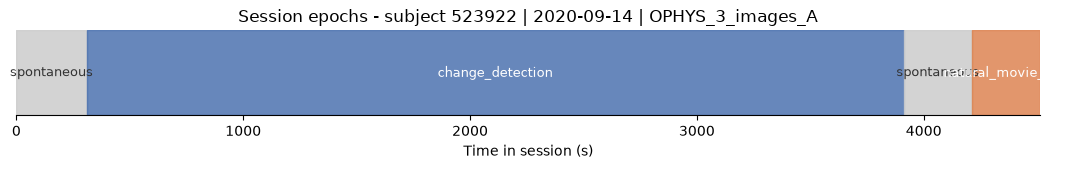

In [29]:
# Title metadata: subject id, acquisition date, session type.
subject_id = getattr(nwb.subject, 'subject_id', '?') if nwb.subject is not None else '?'
acq_date = nwb.session_start_time.strftime('%Y-%m-%d') if nwb.session_start_time else '?'
_tp = nwb.lab_meta_data.get('task_parameters')
session_type = (getattr(_tp, 'session_type', None) if _tp is not None else None) \
               or nwb.session_description or '?'

fig, ax = plt.subplots(figsize=(11, 1.8))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=EPOCH_COLORS.get(ep['label'], '#888888'), alpha=0.85)
    mid = (ep['start_time'] + ep['stop_time']) / 2
    ax.text(mid, 0.5, ep['label'], ha='center', va='center', fontsize=9,
            color='white' if ep['label'] != 'spontaneous' else '#333333')
ax.set_xlim(0, float(epochs['stop_time'].max()))
ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time in session (s)')
ax.set_title(f'Session epochs - subject {subject_id} | {acq_date} | {session_type}')
for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** 1-minute zoom showing each interval type as a colored row.

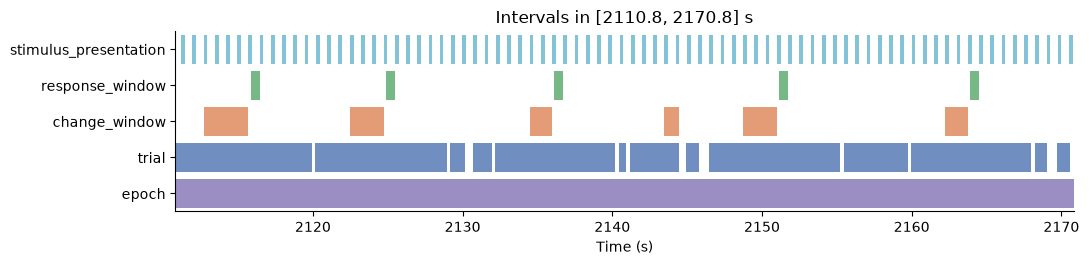

In [30]:
fig, ax = plt.subplots(figsize=(11, max(2, 0.55 * len(present))))
for row_idx, itype in enumerate(present):
    rows = intervals[(intervals['interval_type'] == itype)
                     & (intervals['start_time'] < t1)
                     & (intervals['stop_time'] > t0)]
    for _, r in rows.iterrows():
        ax.add_patch(plt.Rectangle((r['start_time'], row_idx + 0.1),
                     max(r['stop_time'] - r['start_time'], 0.01), 0.8,
                     color=ITYPE_COLORS[itype], alpha=0.8, lw=0))
ax.set_xlim(t0, t1); ax.set_ylim(0, len(present))
ax.set_yticks([i + 0.5 for i in range(len(present))]); ax.set_yticklabels(present)
ax.set_xlabel('Time (s)'); ax.set_title(f'Intervals in [{t0:.1f}, {t1:.1f}] s')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** same 1-minute window, now with events overlaid on the intervals.

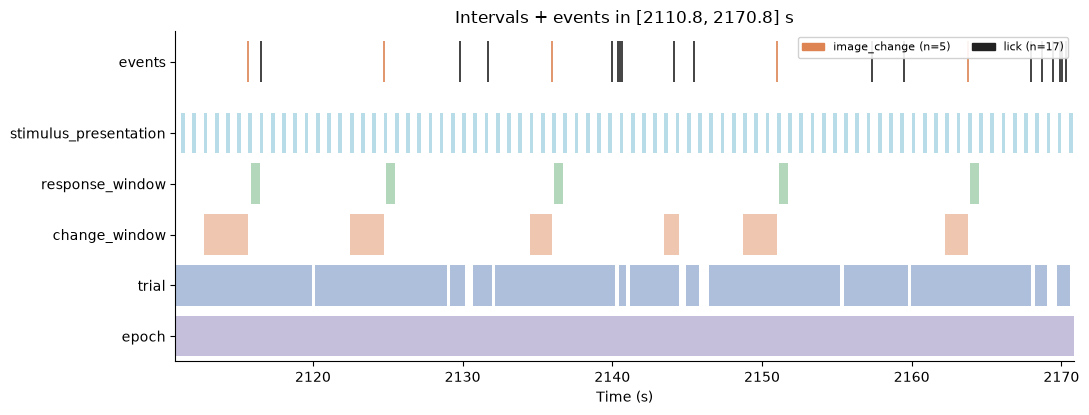

In [31]:
fig, ax = plt.subplots(figsize=(11, max(2.5, 0.55 * len(present) + 1.5)))
for row_idx, itype in enumerate(present):
    rows = intervals[(intervals['interval_type'] == itype)
                     & (intervals['start_time'] < t1)
                     & (intervals['stop_time'] > t0)]
    for _, r in rows.iterrows():
        ax.add_patch(plt.Rectangle((r['start_time'], row_idx + 0.1),
                     max(r['stop_time'] - r['start_time'], 0.01), 0.8,
                     color=ITYPE_COLORS[itype], alpha=0.45, lw=0))
ev_row = len(present) + 0.5
window_ev = events[(events['timestamp'] >= t0) & (events['timestamp'] <= t1)]
handles = []
for etype, color in EVENT_COLORS.items():
    sub = window_ev[window_ev['event_type'] == etype]
    if len(sub):
        ax.vlines(sub['timestamp'], ev_row, ev_row + 0.8, color=color, lw=1.2)
        handles.append(mpatches.Patch(color=color, label=f'{etype} (n={len(sub)})'))
ax.set_xlim(t0, t1); ax.set_ylim(0, len(present) + 1.5)
ax.set_yticks([i + 0.5 for i in range(len(present))] + [ev_row + 0.4])
ax.set_yticklabels(present + ['events'])
ax.set_xlabel('Time (s)'); ax.set_title(f'Intervals + events in [{t0:.1f}, {t1:.1f}] s')
if handles:
    ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** change- and omission-aligned lick distributions. Always drawn;
an empty panel is annotated in red so a session with no licks/changes is obvious.

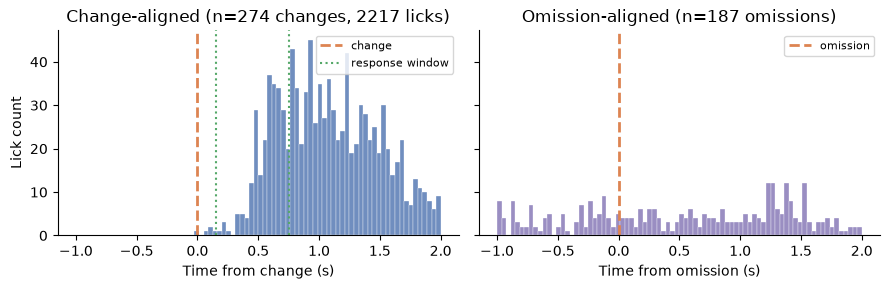

In [32]:
lick_events = events[events['event_type'] == 'lick']
change_events = events[events['event_type'] == 'image_change']
omit_events = events[events['event_type'] == 'image_omission']

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

change_lat = []
for _, ce in change_events.iterrows():
    trial_licks = lick_events[lick_events['trials_id'] == ce['trials_id']]
    lats = trial_licks['timestamp'].values - ce['timestamp']
    change_lat.extend(lats[(lats > -1) & (lats < 2)])
axes[0].hist(change_lat, bins=80, range=(-1, 2), color='#4C72B0', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='#DD8452', ls='--', lw=2, label='change')
axes[0].axvline(0.15, color='#55A868', ls=':', lw=1.5, label='response window')
axes[0].axvline(0.75, color='#55A868', ls=':', lw=1.5)
axes[0].set_xlabel('Time from change (s)'); axes[0].set_ylabel('Lick count')
axes[0].set_title(f'Change-aligned (n={len(change_events)} changes, {len(lick_events)} licks)')
axes[0].legend(fontsize=8)

omit_lat = []
lick_times = lick_events['timestamp'].values
for ot in omit_events['timestamp'].values:
    nearby = lick_times[(lick_times > ot - 1) & (lick_times < ot + 2)]
    omit_lat.extend(nearby - ot)
axes[1].hist(omit_lat, bins=80, range=(-1, 2), color='#8172B3', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='#DD8452', ls='--', lw=2, label='omission')
axes[1].set_xlabel('Time from omission (s)')
axes[1].set_title(f'Omission-aligned (n={len(omit_events)} omissions)')
axes[1].legend(fontsize=8)

# Annotate empties loudly instead of skipping. (No omissions is normal for
# continuously-presented gratings, so that note is gray, not red.)
if len(change_lat) == 0:
    axes[0].text(0.5, 0.5, 'NO licks aligned to changes', transform=axes[0].transAxes,
                 ha='center', va='center', fontsize=12, color='red', fontweight='bold')
if len(omit_lat) == 0:
    axes[1].text(0.5, 0.5, 'no omissions / no licks near them', transform=axes[1].transAxes,
                 ha='center', va='center', fontsize=11, color='#888888', style='italic')
for ax in axes:
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** lick-classification counts and bout-start breakdown (orthogonal
columns). Always drawn; annotated in red if there are no licks.

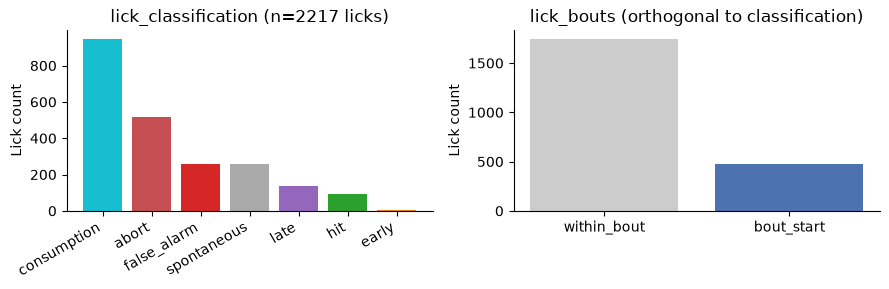

In [33]:
licks = events[events['event_type'] == 'lick'].copy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
LICK_CLS_COLORS = {'hit': '#2ca02c', 'false_alarm': '#d62728', 'abort': '#C44E52',
                   'early': '#ff7f0e', 'late': '#9467bd', 'consumption': '#17becf',
                   'spontaneous': '#aaaaaa'}
cls_counts = licks['lick_classification'].value_counts()
axes[0].bar(range(len(cls_counts)), cls_counts.values,
            color=[LICK_CLS_COLORS.get(c, '#888') for c in cls_counts.index])
axes[0].set_xticks(range(len(cls_counts)))
axes[0].set_xticklabels(cls_counts.index, rotation=30, ha='right')
axes[0].set_ylabel('Lick count')
axes[0].set_title(f'lick_classification (n={len(licks)} licks)')

bout = licks['lick_bouts'].value_counts()
axes[1].bar(range(len(bout)), bout.values, color=['#cccccc', '#4C72B0'][:len(bout)])
axes[1].set_xticks(range(len(bout))); axes[1].set_xticklabels(bout.index)
axes[1].set_ylabel('Lick count')
axes[1].set_title('lick_bouts (orthogonal to classification)')

if len(licks) == 0:
    for ax in axes:
        ax.text(0.5, 0.5, 'NO lick events', transform=ax.transAxes, ha='center',
                va='center', fontsize=13, color='red', fontweight='bold')
for ax in axes:
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** full-session running speed, with epoch backgrounds.

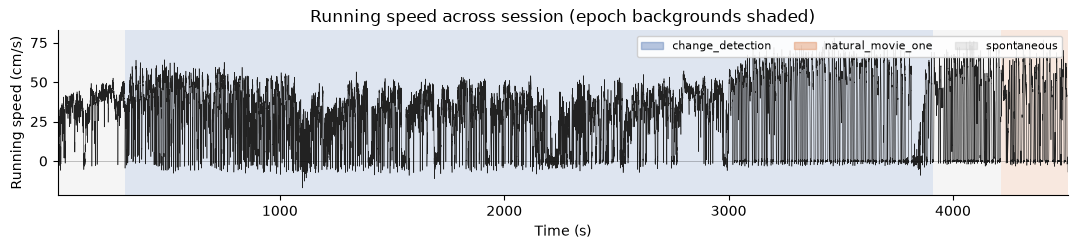

In [34]:
fig, ax = plt.subplots(figsize=(11, 2.6))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=EPOCH_COLORS.get(ep['label'], '#cccccc'), alpha=0.18, lw=0)
if speed is None:
    ax.text(0.5, 0.5, 'MISSING running-speed TimeSeries (REQUIRED - this should always exist)',
            transform=ax.transAxes, ha='center', va='center', fontsize=12,
            color='red', fontweight='bold')
else:
    ax.plot(speed_t, speed, color='#222222', lw=0.4)
    ax.axhline(0, color='k', lw=0.4, alpha=0.4)
    ax.set_xlim(speed_t[0], speed_t[-1])
    ax.set_ylabel('Running speed (cm/s)')
ax.set_xlabel('Time (s)')
ax.set_title('Running speed across session (epoch backgrounds shaded)')
handles = [mpatches.Patch(color=c, alpha=0.4, label=n) for n, c in EPOCH_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=3, framealpha=0.9)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** running speed overlaid on the same 1-minute window (speed + stimulus + events).

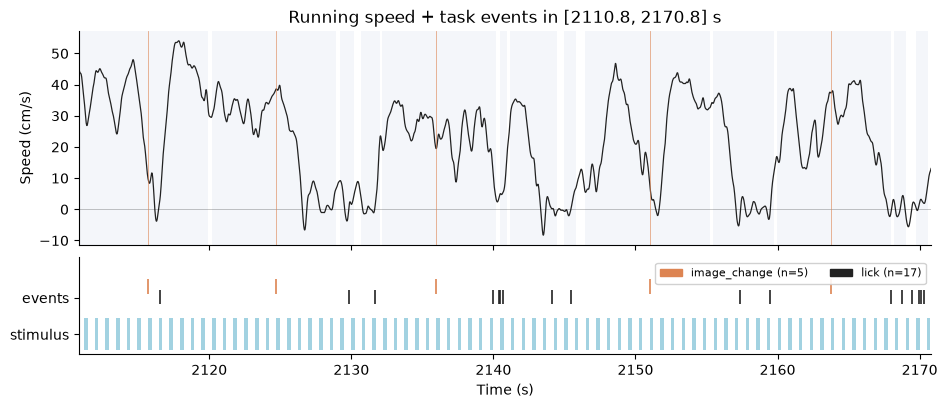

In [35]:
mask = (speed_t >= t0) & (speed_t <= t1) if speed is not None else None
fig, (ax_s, ax_e) = plt.subplots(2, 1, figsize=(11, 4.2), sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.0], 'hspace': 0.08})
if speed is None:
    ax_s.text(0.5, 0.5, 'MISSING running speed (REQUIRED)', transform=ax_s.transAxes, ha='center',
              va='center', fontsize=12, color='red', fontweight='bold')
else:
    ax_s.plot(speed_t[mask], speed[mask], color='#222222', lw=0.9)
    ax_s.axhline(0, color='k', lw=0.4, alpha=0.4)
    ax_s.set_ylabel('Speed (cm/s)')
ax_s.set_title(f'Running speed + task events in [{t0:.1f}, {t1:.1f}] s')

# Bottom axis (stimulus strip + event ticks) always renders - independent of speed.
stim_rows = intervals[(intervals['interval_type'] == 'stimulus_presentation')
                      & (intervals['start_time'] < t1) & (intervals['stop_time'] > t0)]
for _, r in stim_rows.iterrows():
    ax_e.add_patch(plt.Rectangle((r['start_time'], 0.05),
        max(r['stop_time'] - r['start_time'], 0.01), 0.4,
        color=ITYPE_COLORS['stimulus_presentation'], alpha=0.6, lw=0))
tr_rows = intervals[(intervals['interval_type'] == 'trial')
                    & (intervals['start_time'] < t1) & (intervals['stop_time'] > t0)]
for _, r in tr_rows.iterrows():
    ax_s.axvspan(r['start_time'], r['stop_time'], color=ITYPE_COLORS['trial'], alpha=0.06, lw=0)

ev_levels = {'image_change': 0.75, 'image_omission': 0.55, 'reward': 0.95, 'lick': 0.62}
handles = []
window_ev = events[(events['timestamp'] >= t0) & (events['timestamp'] <= t1)]
for etype, color in EVENT_COLORS.items():
    sub = window_ev[window_ev['event_type'] == etype]
    if len(sub):
        y = ev_levels[etype]
        ax_e.vlines(sub['timestamp'], y, y + 0.18, color=color, lw=1.2)
        handles.append(mpatches.Patch(color=color, label=f'{etype} (n={len(sub)})'))
        if etype == 'image_change':
            for t in sub['timestamp']:
                ax_s.axvline(t, color=color, lw=0.6, alpha=0.7)
ax_e.set_xlim(t0, t1); ax_e.set_ylim(0, 1.2)
ax_e.set_yticks([0.25, 0.7]); ax_e.set_yticklabels(['stimulus', 'events'])
ax_e.set_xlabel('Time (s)')
if handles:
    ax_e.legend(handles=handles, loc='upper right', fontsize=8, ncol=4, framealpha=0.9)
for s in ('top', 'right'):
    ax_s.spines[s].set_visible(False); ax_e.spines[s].set_visible(False)
plt.show()

---
## Behavior across trials

One trial per row, time relative to each trial's start. Composes trial/window
shading, stimulus-presentation strip, running speed, and lick/reward marks.

In [36]:
TRIAL_COLOR = '#999999'; STIM_COLOR = '#64B5CD'; CHANGE_COLOR = '#8172B3'
OUTCOMES = ['hit', 'miss', 'false_alarm', 'correct_reject', 'aborted', 'auto_rewarded']


def plot_behavior_across_trials(start_trial=1, n_trials=5, ax=None):
    """Plot behavior for n_trials consecutive trials, one trial per row."""
    last = min(start_trial + n_trials, len(trials))
    trial_ids = list(range(start_trial, last))
    if not trial_ids:
        print('No trials to plot.'); return None, None
    sub = trials.loc[trial_ids]
    max_dur = float((sub['stop_time'] - sub['start_time']).max())

    has_speed = speed is not None
    if has_speed:
        m = (speed_t >= sub['start_time'].min()) & (speed_t <= sub['stop_time'].max())
        vmin, vmax = (np.nanmin(speed[m]), np.nanmax(speed[m])) if m.any() else (0.0, 1.0)
        vspan = max(vmax - vmin, 1e-6)

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, .5 * n_trials))
    else:
        fig = ax.figure
    band, run_lo, run_hi, lick_y = 1.0, 0.10, 0.78, 0.03

    for row, (tid, tr) in enumerate(sub.iterrows()):
        y0 = (len(trial_ids) - 1 - row) * band
        t0t = tr['start_time']
        ax.add_patch(plt.Rectangle((0, y0), tr['stop_time'] - t0t, band,
                     color=TRIAL_COLOR, alpha=0.18, lw=0, zorder=0))
        for win, color in WINDOW_COLORS.items():
            ws, we = tr.get(f'{win}_start_time', np.nan), tr.get(f'{win}_stop_time', np.nan)
            if np.isfinite(ws) and np.isfinite(we):
                ax.add_patch(plt.Rectangle((ws - t0t, y0), we - ws, band,
                             color=color, alpha=0.30, lw=0, zorder=1))
        for _, s in stim[stim['trials_id'] == tid].iterrows():
            if bool(s['omitted']):
                continue
            is_change = bool(s['is_change'])
            ax.add_patch(plt.Rectangle((s['start_time'] - t0t, y0),
                         max(s['stop_time'] - s['start_time'], 0.01), band,
                         color=CHANGE_COLOR if is_change else STIM_COLOR,
                         alpha=0.45 if is_change else 0.30, lw=0, zorder=2))
        if has_speed:
            rm = (speed_t >= t0t) & (speed_t <= tr['stop_time'])
            if rm.any():
                y = y0 + (run_lo + (speed[rm] - vmin) / vspan * (run_hi - run_lo)) * band
                ax.plot(speed_t[rm] - t0t, y, color='#222222', lw=0.7, zorder=3)
        ev = events[(events['timestamp'] >= t0t) & (events['timestamp'] <= tr['stop_time'])]
        lk = ev[ev['event_type'] == 'lick']
        ax.vlines(lk['timestamp'] - t0t, y0 + lick_y, y0 + lick_y + 0.06 * band,
                  color='k', lw=0.8, zorder=4)
        rew = ev[ev['event_type'] == 'reward']
        ax.plot(rew['timestamp'] - t0t, [y0 + lick_y + 0.03 * band] * len(rew),
                marker='v', ls='none', color='#FFD700', ms=7,
                markeredgecolor='k', markeredgewidth=0.4, zorder=5)
        outcome = next((o for o in OUTCOMES if o in tr and tr[o]), '')
        ax.text(-0.015 * max_dur, y0 + band / 2, f'trial {tid}\n{outcome}',
                ha='right', va='center', fontsize=8)

    ax.set_xlim(-0.12 * max_dur, max_dur * 1.02); ax.set_ylim(0, len(trial_ids) * band)
    ax.set_yticks([]); ax.set_xlabel('Time from trial start (s)')
    ax.set_title(f'Behavior across trials {trial_ids[0]}-{trial_ids[-1]}')
    handles = [
        mpatches.Patch(color=TRIAL_COLOR, alpha=0.18, label='trial'),
        mpatches.Patch(color=WINDOW_COLORS['change_window'], alpha=0.30, label='change window'),
        mpatches.Patch(color=WINDOW_COLORS['response_window'], alpha=0.30, label='response window'),
        mpatches.Patch(color=STIM_COLOR, alpha=0.30, label='stimulus flash'),
        mpatches.Patch(color=CHANGE_COLOR, alpha=0.45, label='change flash'),
        plt.Line2D([], [], color='#222222', lw=0.9, label='running speed'),
        plt.Line2D([], [], color='k', lw=0.9, label='lick'),
        plt.Line2D([], [], marker='v', ls='none', color='#FFD700',
                   markeredgecolor='k', label='reward')]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
              fontsize=8, framealpha=0.9)
    for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
    plt.tight_layout(); return fig, ax

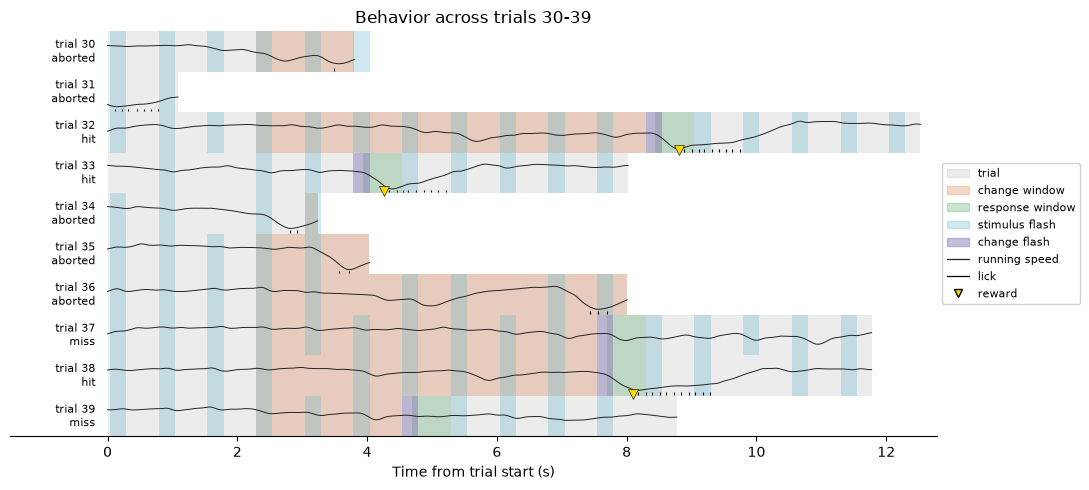

In [37]:
# Change start_trial / n_trials to scan a different stretch of the session.
if len(trials):
    start = min(30, max(len(trials) - 10, 0))
    plot_behavior_across_trials(start_trial=start, n_trials=min(10, len(trials)))
    plt.show()
else:
    print('No trials table - skipping per-trial plot.')

Compact session-overview version: `trials_per_row` consecutive trials laid
end-to-end per row, wrapping to the next row. Unlike the per-trial plot above,
this draws the row **continuously across real session time**, so the inter-trial
intervals are filled in — stimulus flashes, running speed, and licks/rewards
that occur between trials are all shown. The gray boxes mark trial extent; the
ungray spans between them are the ITIs (longer after aborted trials, per
`timeout_duration_sec`). There are no artificial gaps.

In [38]:
def plot_trials_wrapped(start_trial=0, trials_per_row=10, n_rows=5, ax=None):
    """Plot trials as continuous ribbons, trials_per_row per row."""
    last = min(start_trial + trials_per_row * n_rows, len(trials))
    all_ids = list(range(start_trial, last))
    if not all_ids:
        print('No trials to plot.'); return None, None
    rows = [all_ids[i:i + trials_per_row] for i in range(0, len(all_ids), trials_per_row)]
    n_rows = len(rows)

    has_speed = speed is not None
    sub = trials.loc[all_ids]
    if has_speed:
        m = (speed_t >= sub['start_time'].min()) & (speed_t <= sub['stop_time'].max())
        vmin, vmax = (np.nanmin(speed[m]), np.nanmax(speed[m])) if m.any() else (0.0, 1.0)
        vspan = max(vmax - vmin, 1e-6)

    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 1.1 * n_rows))
    else:
        fig = ax.figure
    band, gap, run_lo, run_hi, lick_y = 1.0, 0.18, 0.10, 0.80, 0.03

    def draw_row(ids, y0):
        # The row spans the first trial's start to the last trial's stop, and
        # everything in between - INCLUDING inter-trial intervals - is drawn
        # continuously, so there are no gaps. Trial extent is shown as the gray
        # overlay; ungray spans between gray boxes are the ITIs.
        t_origin = trials.loc[ids[0], 'start_time']
        row_stop = trials.loc[ids[-1], 'stop_time']

        # Stimulus flashes across the whole row span (any trials_id, incl. ITI).
        sp_row = stim[(stim['start_time'] < row_stop) & (stim['stop_time'] > t_origin)]
        for _, s in sp_row.iterrows():
            if bool(s['omitted']):
                continue
            is_change = bool(s['is_change'])
            ax.add_patch(plt.Rectangle((s['start_time'] - t_origin, y0),
                         max(s['stop_time'] - s['start_time'], 0.01), band,
                         color=CHANGE_COLOR if is_change else STIM_COLOR,
                         alpha=0.45 if is_change else 0.30, lw=0, zorder=2))
        # Running speed continuously across the row (incl. ITI).
        if has_speed:
            rm = (speed_t >= t_origin) & (speed_t <= row_stop)
            if rm.any():
                y = y0 + (run_lo + (speed[rm] - vmin) / vspan * (run_hi - run_lo)) * band
                ax.plot(speed_t[rm] - t_origin, y, color='#222222', lw=0.6, zorder=3)
        # Licks & rewards across the row (incl. ITI).
        ev = events[(events['timestamp'] >= t_origin) & (events['timestamp'] <= row_stop)]
        lk = ev[ev['event_type'] == 'lick']
        ax.vlines(lk['timestamp'] - t_origin, y0 + lick_y, y0 + lick_y + 0.05 * band,
                  color='k', lw=0.6, zorder=4)
        rew = ev[ev['event_type'] == 'reward']
        ax.plot(rew['timestamp'] - t_origin, [y0 + lick_y + 0.025 * band] * len(rew),
                marker='v', ls='none', color='#FFD700', ms=5,
                markeredgecolor='k', markeredgewidth=0.3, zorder=5)
        # Per-trial overlays on top: gray trial box, white start separator, and
        # change/response windows.
        for tid in ids:
            tr = trials.loc[tid]; t0t = tr['start_time']
            ax.add_patch(plt.Rectangle((t0t - t_origin, y0), tr['stop_time'] - t0t, band,
                         color=TRIAL_COLOR, alpha=0.18, lw=0, zorder=0))
            ax.plot([t0t - t_origin, t0t - t_origin], [y0, y0 + band],
                    color='white', lw=0.6, zorder=2.5)
            for win, color in WINDOW_COLORS.items():
                ws, we = tr.get(f'{win}_start_time', np.nan), tr.get(f'{win}_stop_time', np.nan)
                if np.isfinite(ws) and np.isfinite(we):
                    ax.add_patch(plt.Rectangle((ws - t_origin, y0), we - ws, band,
                                 color=color, alpha=0.30, lw=0, zorder=1))
        return row_stop - t_origin

    max_span = 0.0
    for r, ids in enumerate(rows):
        y0 = (n_rows - 1 - r) * (band + gap)
        max_span = max(max_span, draw_row(ids, y0))
        ax.text(-0.01 * max_span, y0 + band / 2, f'trials\n{ids[0]}-{ids[-1]}',
                ha='right', va='center', fontsize=8)

    ax.set_xlim(-0.06 * max_span, max_span * 1.01); ax.set_ylim(-gap, n_rows * (band + gap))
    ax.set_yticks([]); ax.set_xlabel('Time within row (s)')
    ax.set_title(f'Behavior across trials {all_ids[0]}-{all_ids[-1]} ({trials_per_row} trials per row)')
    handles = [
        mpatches.Patch(color=TRIAL_COLOR, alpha=0.18, label='trial'),
        mpatches.Patch(color=WINDOW_COLORS['change_window'], alpha=0.30, label='change window'),
        mpatches.Patch(color=WINDOW_COLORS['response_window'], alpha=0.30, label='response window'),
        mpatches.Patch(color=STIM_COLOR, alpha=0.30, label='stimulus flash'),
        mpatches.Patch(color=CHANGE_COLOR, alpha=0.45, label='change flash'),
        plt.Line2D([], [], color='#222222', lw=0.9, label='running speed'),
        plt.Line2D([], [], color='k', lw=0.9, label='lick'),
        plt.Line2D([], [], marker='v', ls='none', color='#FFD700',
                   markeredgecolor='k', label='reward')]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
              fontsize=8, framealpha=0.9)
    for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
    plt.tight_layout(); return fig, ax

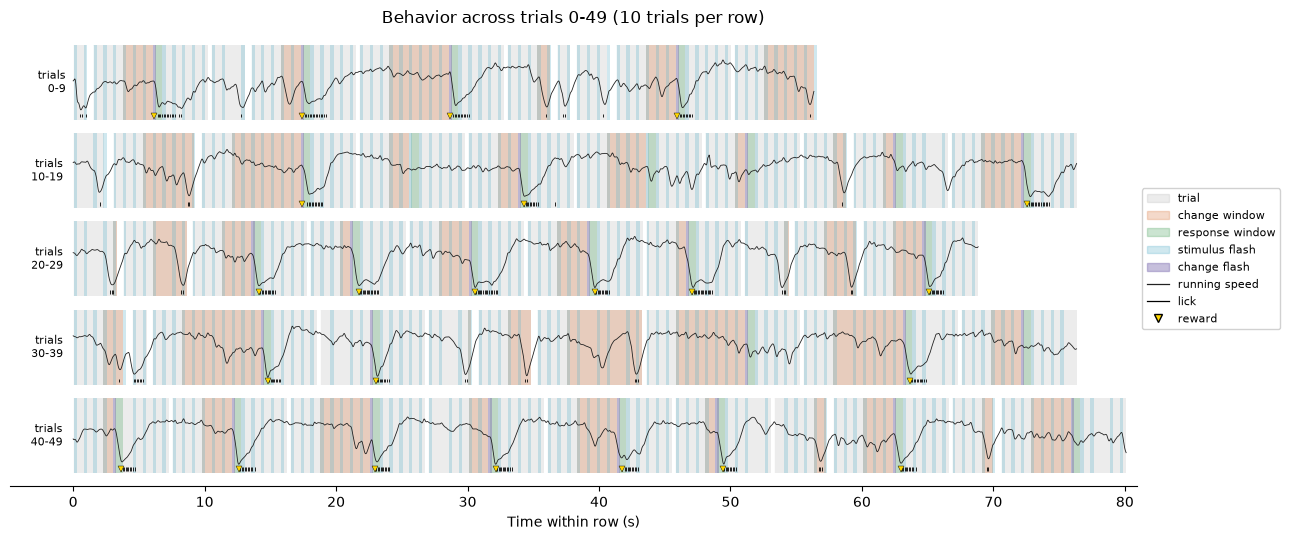

In [39]:
if len(trials):
    plot_trials_wrapped(start_trial=0, trials_per_row=10,
                        n_rows=min(5, int(np.ceil(len(trials) / 10))))
    plt.show()
else:
    print('No trials table - skipping wrapped-trials plot.')

In [40]:
io.close()
print('OK - NWB loaded, inspected, and validation plots rendered.')

OK - NWB loaded, inspected, and validation plots rendered.
